## Linear Regression for Pumpkins - Lesson 2

<span style="color:red">**Note: Students need to complete the cells of the notebook.**</span>

## Loading the data
In this part we will import the librairies we are going to use, load the data and have a first glance at them

In [2]:
#It is a common good practise in code to define the variables at the beginning of the code so that it is easier to change them later on
#update the variables here according to the location of your data file
DATA_FOLDER = "data"
DATA_FILE = "US-pumpkins.xlsx"

In [1]:
#importing librairies for our work

#pandas is the most popular librairy for manipulating small to medium size tabular datasets (if you are interseted in big data, you should look spark)
import pandas as pd

#matplotlib is the most popular librairy for plotting data. Plotting data is a very important part of data analysis because it allows you to visualise the data and understand it better
import matplotlib.pyplot as plt

#os is a librairy that allows you to interact with the operating system. It is very useful to manipulate files and folders independently of the operating system you are using (mac/linux/windows)
import os

In [ ]:
#DATA_FILE_PATH = os.path.join(DATA_FOLDER, DATA_FILE)

In [8]:
#TODO : load the data from the excel file into a pandas dataframe using the pd.read_excel function

pumpkins = pd.read_excel('US-pumpkins.xlsx')
 

In [9]:
#TODO get a cleaner view of the data by using the head() function the usage is df.head(n) where n is the number of rows you want to display, default being 5
pumpkins.head(5)

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,2017-04-29,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,2017-05-06,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,2016-09-24,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,2016-09-24,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,2016-11-05,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [10]:
#TODO : vizualize the columns of the dataframe using the columns attribute of the dataframe
pumpkins.columns

Index(['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Grade',
       'Date', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High',
       'Origin', 'Origin District', 'Item Size', 'Color', 'Environment',
       'Unit of Sale', 'Quality', 'Condition', 'Appearance', 'Storage', 'Crop',
       'Repack', 'Trans Mode', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='str')

In [ ]:
#you can get a summary of the data by using the info() function
#if could also be useful to use the describe() function to get a summary of the numerical columns
#TODO : get a summary of the data using the info() and describe() functions

pumpkins.info()
pumpkins.describe()



<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   City Name        1757 non-null   str           
 1   Type             45 non-null     str           
 2   Package          1757 non-null   str           
 3   Variety          1752 non-null   str           
 4   Sub Variety      296 non-null    str           
 5   Grade            0 non-null      float64       
 6   Date             1757 non-null   datetime64[us]
 7   Low Price        1757 non-null   float64       
 8   High Price       1757 non-null   float64       
 9   Mostly Low       1654 non-null   float64       
 10  Mostly High      1654 non-null   float64       
 11  Origin           1754 non-null   str           
 12  Origin District  131 non-null    str           
 13  Item Size        1478 non-null   str           
 14  Color            1141 non-null   str           
 15

,Grade,Date,Low Price,High Price,Mostly Low,Mostly High,Environment,Quality,Condition,Appearance,Storage,Crop,Trans Mode,Unnamed: 24
count,0.0,1757,1757.000000,1757.000000,1654.000000,1654.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,2017-01-05 09:18:57.165623,124.571338,132.970939,128.170550,132.491802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2014-11-29 00:00:00,0.240000,0.240000,0.240000,0.240000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2016-10-08 00:00:00,24.000000,24.500000,24.625000,26.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2016-10-22 00:00:00,140.000000,150.000000,147.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2017-01-28 00:00:00,180.000000,200.000000,185.000000,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2017-09-30 00:00:00,480.000000,480.000000,480.000000,480.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,83.876591,89.524958,86.512161,88.442967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Remove invalide rows and columns

In this part, we will do a first cleaning of the data in order to be able to vizualize them.

In [12]:
#TODO : get the unique values of the 'Variety' column using the unique() function
pumpkins['Variety'].unique()

<StringArray>
[                       nan,              'HOWDEN TYPE',
        'HOWDEN WHITE TYPE',               'CINDERELLA',
                'FAIRYTALE',                 'PIE TYPE',
            'BIG MACK TYPE', 'MIXED HEIRLOOM VARIETIES',
                'MINIATURE',                'BLUE TYPE',
             'KNUCKLE HEAD']
Length: 11, dtype: str

In [13]:
#TODO : select the subset of columns that you are interested in.
#The columns that you are interested in are the 'City Name', 'Variety', 'Low Price', 'High Price', 'Date'
#You can select the columns by passing a list of the column names to the dataframe like this : df[['column1', 'column2', 'column3']]
df = pumpkins[['City Name', 'Variety', 'Low Price', 'High Price', 'Date']]

In [14]:
df.isna().sum()

City Name     0
Variety       5
Low Price     0
High Price    0
Date          0
dtype: int64

## Vizualization

Now that we have a clean dataset, we will try to get more insights of it with the power of vizualization

#### Scatter plot

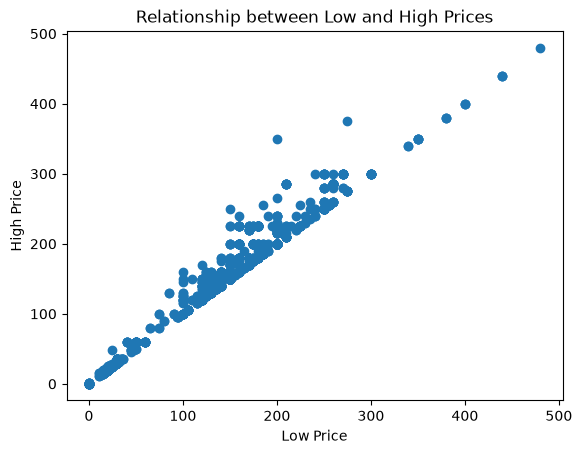

In [15]:
#the scatter plot is a very useful plot to show the relationship between two numerical variables
#it basically creates a dot for each data point, enabling you find correlations
#TODO : plot the 'Low Price' against the 'High Price' using the scatter plot
#you can use the scatter function from matplotlib.pyplot like this : plt.scatter(df[x], df[y]) where x and y are the columns you want to plot
#you can also add labels to the x and y axis using the xlabel and ylabel functions from matplotlib.pyplot
import matplotlib.pyplot as plt

plt.scatter(df['Low Price'], df['High Price'])
plt.xlabel('Low Price')
plt.ylabel('High Price')
plt.title('Relationship between Low and High Prices')
plt.show()


#### groupping the values

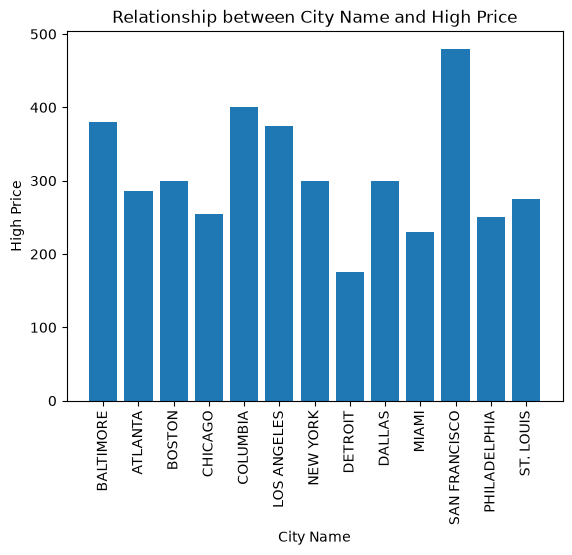

In [19]:
#the bar plot is a very useful plot to show the relationship between a numerical variable and a categorical variable
#it basically creates a bar for each category, enabling you to see the relationship between the two variables
#TODO : plot the 'High Price' against the 'City Name' using the bar plot
#you can use the bar function from matplotlib.pyplot like this : plt.bar(df[x], df[y]) where x is the categorical variable and y is the numerical variable
plt.bar(df['City Name'], df['High Price'])
plt.xlabel('City Name')
plt.ylabel('High Price')
plt.title('Relationship between City Name and High Price')
plt.xticks(rotation=90)
plt.show()

In [20]:
#In order to do the same visualisation for the variety, we need to deal with the rows that are missing values
#TODO : fill the missing values in the 'Variety' column with 'UNKNOWN'
#you can use the fillna function from pandas like this : df['column'] = df['column'].fillna('value')
df['Variety'] = df['Variety'].fillna('UNKNOWN')

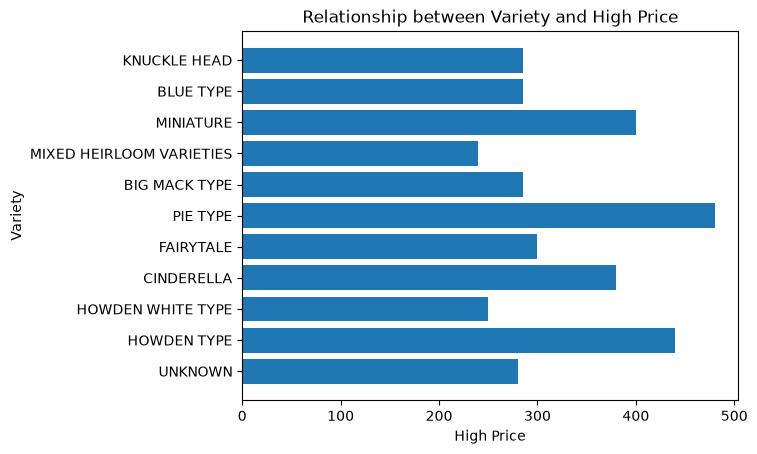

In [21]:
#TODO : plot the 'High Price' against the 'Variety' using the barh plot
#you can use the barh function from matplotlib.pyplot like this : plt.barh(df[x], df[y]) where x is the categorical variable and y is the numerical variable
plt.barh(df['Variety'], df['High Price'])
plt.xlabel('High Price')
plt.ylabel('Variety')
plt.title('Relationship between Variety and High Price')
plt.show()

#### time evolution vizualization
In this part, we will develop a more complex way to vizualize the data evolution

<Axes: xlabel='Date', ylabel='High Price'>

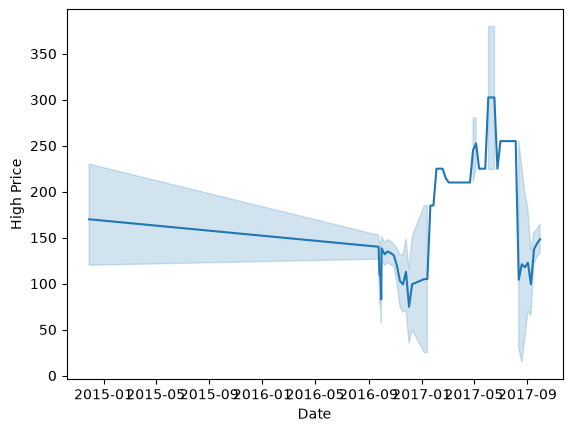

In [23]:
#TODO : plot the 'High Price' against the 'Date' using the scatter plot
#plt.scatter(df['Date'], df['High Price'])
#plt.xlabel('Date')
#plt.ylabel('High Price')
#plt.title('Relationship between Date and High Price')
#plt.xticks(rotation=90)
#plt.show()
import seaborn as sns
sns.lineplot(data=df, x='Date', y='High Price')

<Axes: xlabel='Date', ylabel='High Price'>

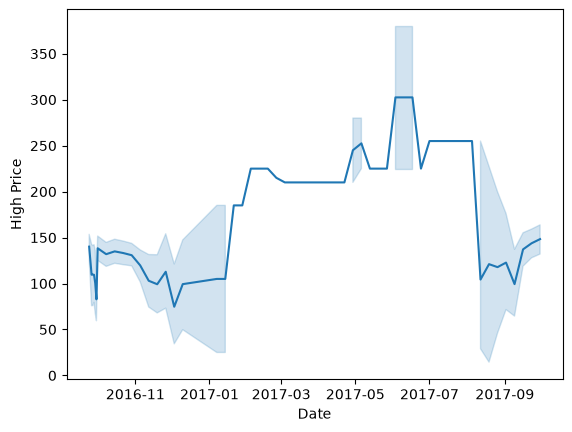

In [24]:
#TODO : filter the data to only keep the data from 2016 and after
#you can filter the data by using the following syntax : df = df[df['column'] > 'date']
#afterwards, plot the 'High Price' against the 'Date' again using the scatter plot
df = df[df['Date'] >= '2016-01-01']
sns.lineplot(data=df, x='Date', y='High Price')

<Axes: xlabel='Month', ylabel='High Price'>

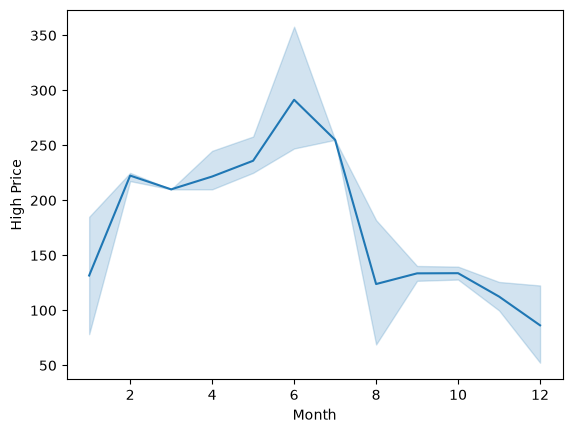

In [25]:
#TODO : create a new column 'Month' that contains the month of the date
#you can use the pd.DatetimeIndex function to extract the month from the date
#TODO plot the 'High Price' against the 'Month' using the line plot
#you can use the plot function from matplotlib.pyplot like this : plt.plot(df[x], df[y])
mdf = pd.DatetimeIndex(df['Date']).month
df['Month'] = mdf 
sns.lineplot(data=df, x='Month', y='High Price')


<Axes: xlabel='Date', ylabel='Price'>

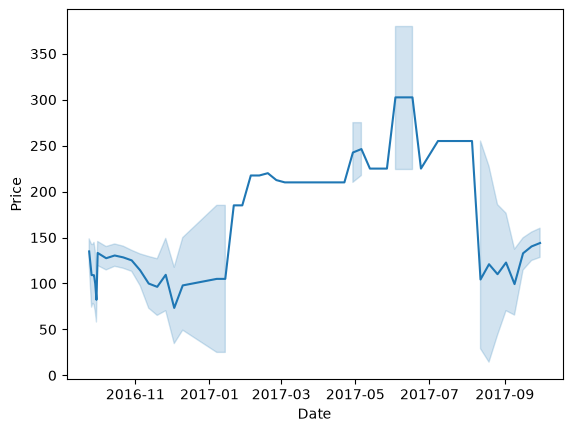

In [27]:
#TODO : create a new column 'Price' that contains the average price between the 'Low Price' and the 'High Price'
#you can use the following syntax : df['column'] = (df['column1'] + df['column2']) / 2
df['Price'] = (df['Low Price'] + df['High Price']) / 2
sns.lineplot(data=df, x='Date', y='Price')


## Optional more advanced: vizualizing correlations between the columns



In [ ]:
import seaborn as sns

In [34]:
#TODO : import newly the data from the excel file into a pandas dataframe using the pd.read_excel function
#TODO: remove columns that have less than 1000 values
#TODO : fill all missing values with the median of the column for numerical columns (float, int or datetime for instance)
#TODO : for categorical columns, fill missing values with 'UNKNOWN'
#TODO : transform categorical columns into numerical columns using 1 hot encoding
#TODO : create a columm price that is the average of the low price and the high price
#pumpkins = pd.read_excel(DATA_FILE_PATH)
df2 = pd.read_excel('US-pumpkins.xlsx') 
df2 = df2.dropna(thresh=1000, axis=1)
for column in df2.columns:
    if df2[column].dtype in ['float64', 'int64', 'datetime64[ns]']:
        df2[column] = df2[column].fillna(df2[column].median())
    else:
        df2[column] = df2[column].fillna('UNKNOWN')
df2 = pd.get_dummies(df2, drop_first=True)
df2['Price'] = (df2['Low Price'] + df2['High Price']) / 2


<Axes: >

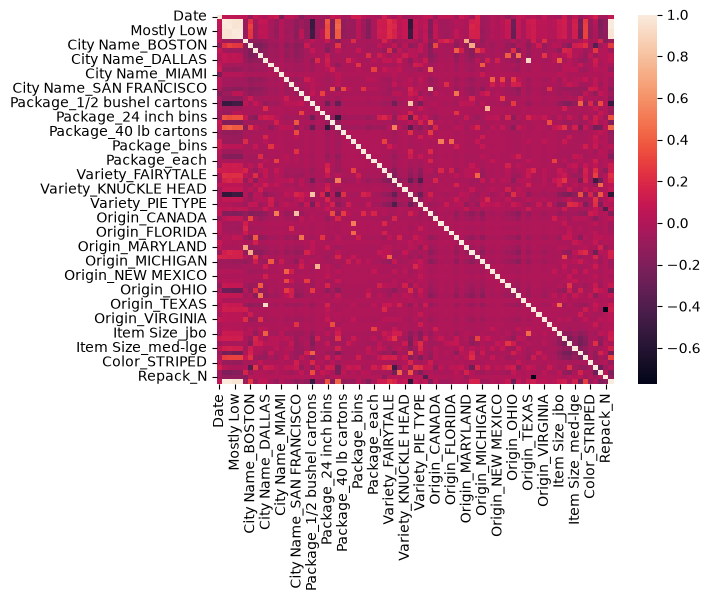

In [35]:
#TODO : calculate the correlation matrix of the data with the column 'Price'
#you can use the corr() function from pandas like this : df.corr()
#Select only the rows having the highest correlation with the 'Price' column
#Plot the correlation matrix using the heatmap function from seaborn like this : sns.heatmap(df)
df2_corr = df2.corr()
price_corr = df2_corr['Price'].sort_values(ascending=False) 
sns.heatmap(df2_corr)
